# Binned Local RMSE / CRPS Heatmaps

This notebook evaluates local predictive performance on the stored `pt+mtmh_2000` results. It selects the two most important features for each dataset, builds shared 2D bins from the test locations, and plots one heatmap per method for RMSE and CRPS.

Feature importance rule: fit a `RandomForestRegressor` on a train split of the cached full dataset, compute permutation importance on a held-out validation split, and select the top two features by mean importance. This is model-agnostic with respect to the four BART samplers, so the bin axes are not chosen to favor any one method.

## Config

In [1]:
from pathlib import Path
import ast
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

STORE_ROOT = Path("store")
METHODS = ["default", "default_pt", "mtmh", "mtmh_pt"]
DATASETS = [
    "real1_Abalone_pt_mtmh",
    "real2_WineQuality_pt_mtmh",
    "real3_CalHousing_pt_mtmh",
    "real4_Concrete_pt_mtmh",
    "syn1_Friedman_pt_mtmh",
]

N_BINS = 5
MIN_POINTS_PER_BIN = 5
RF_RANDOM_STATE = 2026
PERMUTATION_REPEATS = 20
SAVE_FIGURES = False
OUTPUT_DIR = Path("binned_local_metric_figures")

FEATURE_NAMES = {
    "real1_Abalone_pt_mtmh": ["Length", "Diameter", "Height", "Whole weight", "Shucked weight", "Viscera weight", "Shell weight"],
    "real2_WineQuality_pt_mtmh": ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates", "alcohol"],
    "real3_CalHousing_pt_mtmh": ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"],
    "real4_Concrete_pt_mtmh": ["Cement", "Blast Furnace Slag", "Fly Ash", "Water", "Superplasticizer", "Coarse Aggregate", "Fine Aggregate", "Age"],
    "syn1_Friedman_pt_mtmh": [f"x{i}" for i in range(1, 11)],
}

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

## Helpers

Everything below only defines functions. The actual computation and plotting happens in the final section.

In [2]:
def read_original_shape(path: Path):
    with path.open("r", encoding="utf-8") as f:
        first = f.readline().strip()
    match = re.search(r"original_shape=(.*)$", first)
    return tuple(ast.literal_eval(match.group(1))) if match else None


def load_numeric_csv(path: Path, restore_shape: bool = True):
    arr = np.loadtxt(path, delimiter=",", comments="#")
    arr = np.atleast_2d(arr)
    shape = read_original_shape(path)
    if restore_shape and shape:
        return arr.reshape(shape)
    return arr


def crps_from_samples(samples, y_true):
    samples = np.asarray(samples)
    y_true = np.asarray(y_true).reshape(-1)
    n_points, n_samples = samples.shape
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples**2)
    return term1 - term2


def prediction_samples_by_point(preds):
    """Return posterior samples with shape (n_points, n_samples)."""
    preds = np.asarray(preds)
    if preds.ndim == 3:
        return np.transpose(preds, (1, 0, 2)).reshape(preds.shape[1], -1)
    if preds.ndim == 2:
        return preds
    raise ValueError(f"Unsupported preds shape: {preds.shape}")


def available_runs(dataset):
    files = sorted((STORE_ROOT / "subsample_X_test").glob(f"{dataset}__run*__subsample_X_test.csv"))
    return [int(re.search(r"__run(\d+)__", f.name).group(1)) for f in files]


def run_tag(dataset, run_id):
    return f"{dataset}__run{run_id:03d}"


def select_top_features(dataset, n_repeats=PERMUTATION_REPEATS):
    cache = np.load(STORE_ROOT / "dataset_cache" / f"{dataset}.npz")
    X, y = cache["X"], cache["y"]
    names = FEATURE_NAMES.get(dataset, [f"x{i + 1}" for i in range(X.shape[1])])

    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.25, random_state=RF_RANDOM_STATE
    )
    rf = RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=RF_RANDOM_STATE,
    )
    rf.fit(X_train, y_train)
    imp = permutation_importance(
        rf,
        X_valid,
        y_valid,
        n_repeats=n_repeats,
        random_state=RF_RANDOM_STATE,
        n_jobs=-1,
    )
    table = pd.DataFrame({
        "feature_index": np.arange(X.shape[1]),
        "feature": names,
        "importance_mean": imp.importances_mean,
        "importance_std": imp.importances_std,
    }).sort_values("importance_mean", ascending=False, ignore_index=True)
    top_features = table.loc[:1, "feature_index"].to_numpy(dtype=int)
    top_feature_names = table.loc[:1, "feature"].tolist()
    return table, top_features, top_feature_names


def collect_pointwise_metrics(dataset, feature_indices):
    rows = []
    runs = available_runs(dataset)
    if not runs:
        raise FileNotFoundError(f"No runs found for {dataset}")

    for run_id in runs:
        tag = run_tag(dataset, run_id)
        X_test = load_numeric_csv(STORE_ROOT / "subsample_X_test" / f"{tag}__subsample_X_test.csv")
        y_test = load_numeric_csv(STORE_ROOT / "subsample_y_test" / f"{tag}__subsample_y_test.csv").reshape(-1)

        for method in METHODS:
            preds = load_numeric_csv(STORE_ROOT / "preds" / f"{tag}__{method}__preds.csv")
            samples = prediction_samples_by_point(preds)
            pred_mean = samples.mean(axis=1)
            crps = crps_from_samples(samples, y_test)
            squared_error = (y_test - pred_mean) ** 2

            rows.append(pd.DataFrame({
                "run_id": run_id,
                "method": method,
                "x1": X_test[:, feature_indices[0]],
                "x2": X_test[:, feature_indices[1]],
                "y": y_test,
                "pred_mean": pred_mean,
                "squared_error": squared_error,
                "crps": crps,
            }))

    return pd.concat(rows, ignore_index=True)


def quantile_edges(values, n_bins):
    edges = np.quantile(values, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    if len(edges) <= 2:
        edges = np.linspace(np.nanmin(values), np.nanmax(values), n_bins + 1)
    edges[0] = -np.inf
    edges[-1] = np.inf
    return edges


def add_shared_bins(df, n_bins):
    locations = df[["run_id", "x1", "x2"]].drop_duplicates()
    x1_edges = quantile_edges(locations["x1"].to_numpy(), n_bins)
    x2_edges = quantile_edges(locations["x2"].to_numpy(), n_bins)

    out = df.copy()
    out["x1_bin"] = pd.cut(out["x1"], bins=x1_edges, labels=False, include_lowest=True)
    out["x2_bin"] = pd.cut(out["x2"], bins=x2_edges, labels=False, include_lowest=True)
    return out, x1_edges, x2_edges


def binned_metrics(df, min_points=MIN_POINTS_PER_BIN):
    grouped = (
        df.groupby(["method", "x2_bin", "x1_bin"], observed=False)
        .agg(
            n=("squared_error", "size"),
            rmse=("squared_error", lambda s: float(np.sqrt(np.mean(s)))),
            crps=("crps", "mean"),
        )
        .reset_index()
    )
    grouped.loc[grouped["n"] < min_points, ["rmse", "crps"]] = np.nan
    return grouped


def edge_label(edges, i):
    left = edges[i]
    right = edges[i + 1]
    left_s = "-inf" if np.isneginf(left) else f"{left:.2g}"
    right_s = "inf" if np.isposinf(right) else f"{right:.2g}"
    return f"[{left_s}, {right_s})"


def matrix_for_method(table, method, metric, x1_edges, x2_edges):
    sub = table[table["method"] == method]
    mat = sub.pivot(index="x2_bin", columns="x1_bin", values=metric)
    mat = mat.reindex(index=range(len(x2_edges) - 1), columns=range(len(x1_edges) - 1))
    return mat


def plot_metric_heatmaps(table, metric, dataset, feature_names, x1_edges, x2_edges, cmap="viridis"):
    mats = {method: matrix_for_method(table, method, metric, x1_edges, x2_edges) for method in METHODS}
    values = np.concatenate([m.to_numpy().ravel() for m in mats.values()])
    values = values[np.isfinite(values)]
    vmin, vmax = (float(values.min()), float(values.max())) if len(values) else (0.0, 1.0)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
    xlabels = [edge_label(x1_edges, i) for i in range(len(x1_edges) - 1)]
    ylabels = [edge_label(x2_edges, i) for i in range(len(x2_edges) - 1)]

    for ax, method in zip(axes.ravel(), METHODS):
        mat = mats[method]
        im = ax.imshow(mat.to_numpy(), origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(method)
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
        ax.set_xticks(range(len(xlabels)), labels=xlabels, rotation=35, ha="right")
        ax.set_yticks(range(len(ylabels)), labels=ylabels)

        for y_idx in range(mat.shape[0]):
            for x_idx in range(mat.shape[1]):
                value = mat.iloc[y_idx, x_idx]
                if np.isfinite(value):
                    ax.text(x_idx, y_idx, f"{value:.3g}", ha="center", va="center", color="white", fontsize=9)
                else:
                    ax.text(x_idx, y_idx, "NA", ha="center", va="center", color="0.3", fontsize=8)

    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.86, label=metric.upper())
    fig.suptitle(f"{dataset}: binned {metric.upper()} on {feature_names[0]} x {feature_names[1]}", fontsize=14)
    return fig


def analyze_dataset(dataset, n_bins=N_BINS):
    importance_table, top_features, top_feature_names = select_top_features(dataset)
    pointwise = collect_pointwise_metrics(dataset, top_features)
    pointwise, x1_edges, x2_edges = add_shared_bins(pointwise, n_bins)
    table = binned_metrics(pointwise)
    return {
        "dataset": dataset,
        "importance_table": importance_table,
        "top_features": top_features,
        "top_feature_names": top_feature_names,
        "binned": table,
        "x1_edges": x1_edges,
        "x2_edges": x2_edges,
    }


def plot_dataset_metrics(result):
    dataset = result["dataset"]
    feature_names = result["top_feature_names"]
    table = result["binned"]
    x1_edges = result["x1_edges"]
    x2_edges = result["x2_edges"]

    rmse_fig = plot_metric_heatmaps(table, "rmse", dataset, feature_names, x1_edges, x2_edges, cmap="magma")
    crps_fig = plot_metric_heatmaps(table, "crps", dataset, feature_names, x1_edges, x2_edges, cmap="viridis")
    return rmse_fig, crps_fig


def save_figures(dataset, rmse_fig, crps_fig):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    rmse_fig.savefig(OUTPUT_DIR / f"{dataset}__binned_rmse.png", bbox_inches="tight")
    crps_fig.savefig(OUTPUT_DIR / f"{dataset}__binned_crps.png", bbox_inches="tight")

## Run All Datasets

Run this cell after the config and helper cells. It computes the top-two feature axes per dataset, then draws RMSE and CRPS heatmaps for every dataset.


=== real1_Abalone_pt_mtmh ===


,feature_index,feature,importance_mean,importance_std
0,6,Shell weight,1.419430,0.058179
1,4,Shucked weight,0.608190,0.031098
2,3,Whole weight,0.093995,0.013331
3,2,Height,0.039882,0.005715
4,5,Viscera weight,0.025431,0.005430
5,0,Length,0.013222,0.004057
6,1,Diameter,0.009103,0.003833


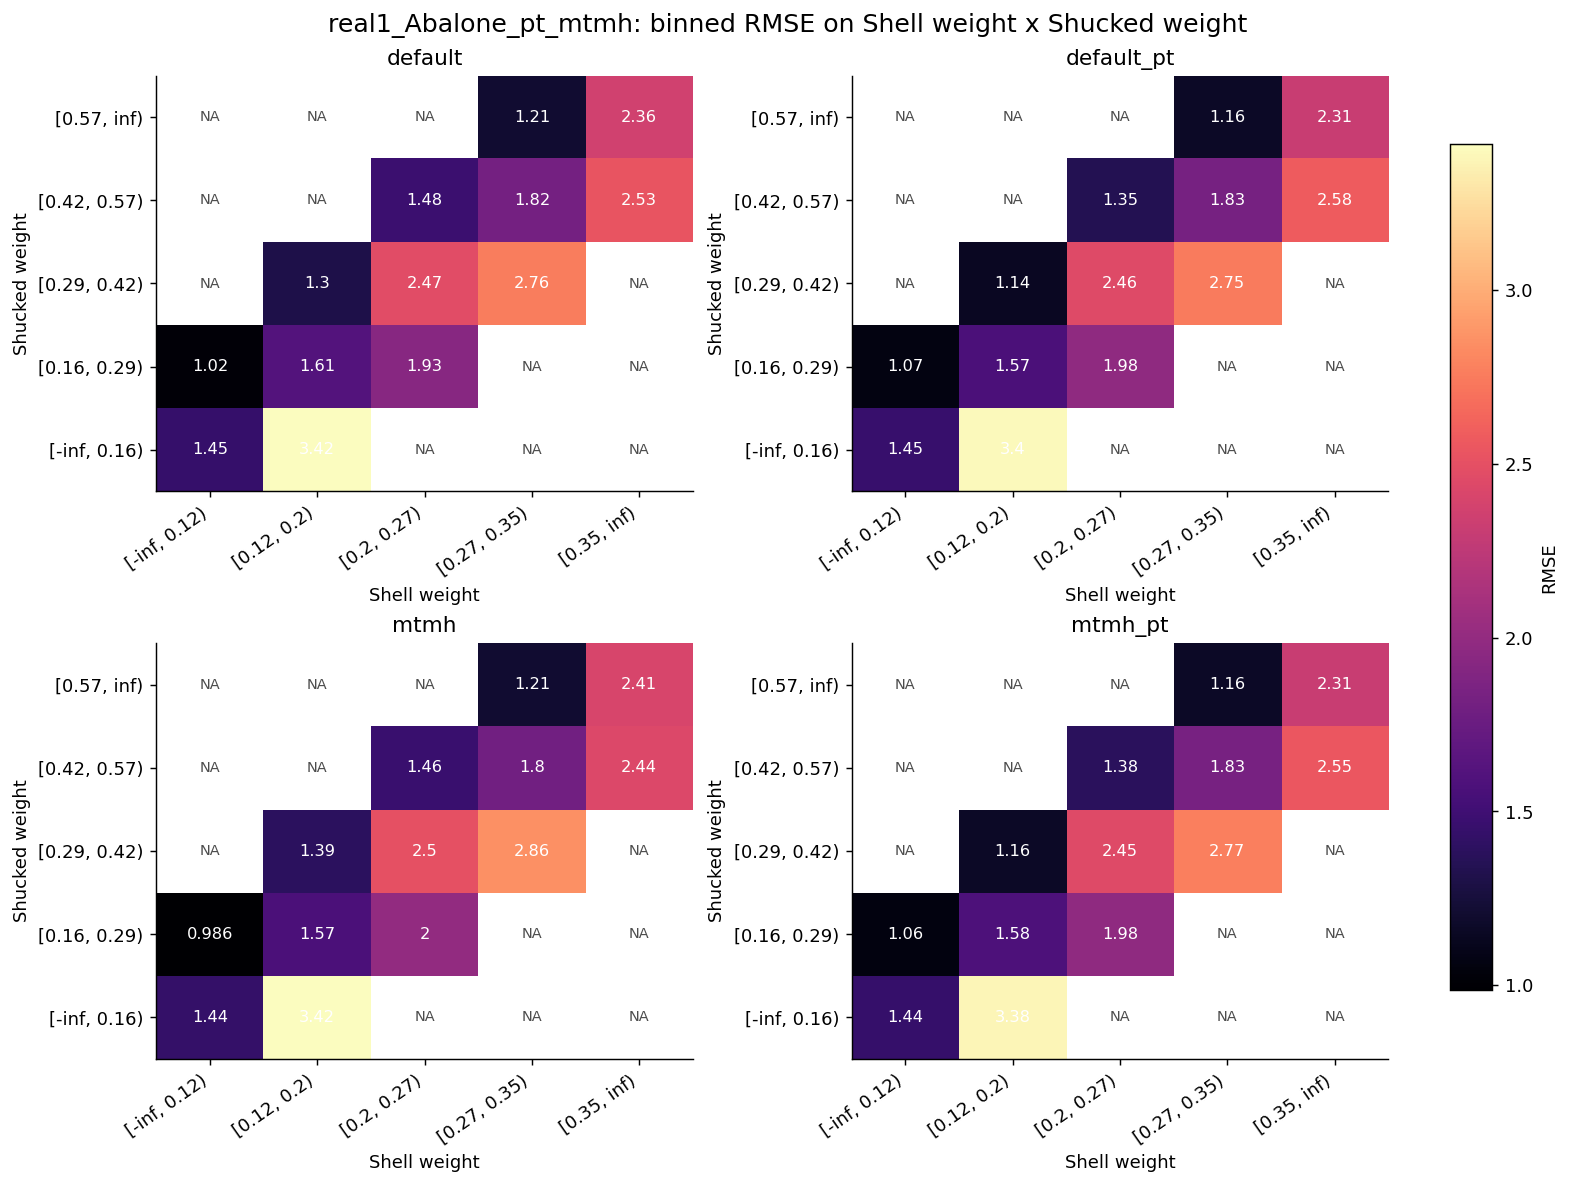

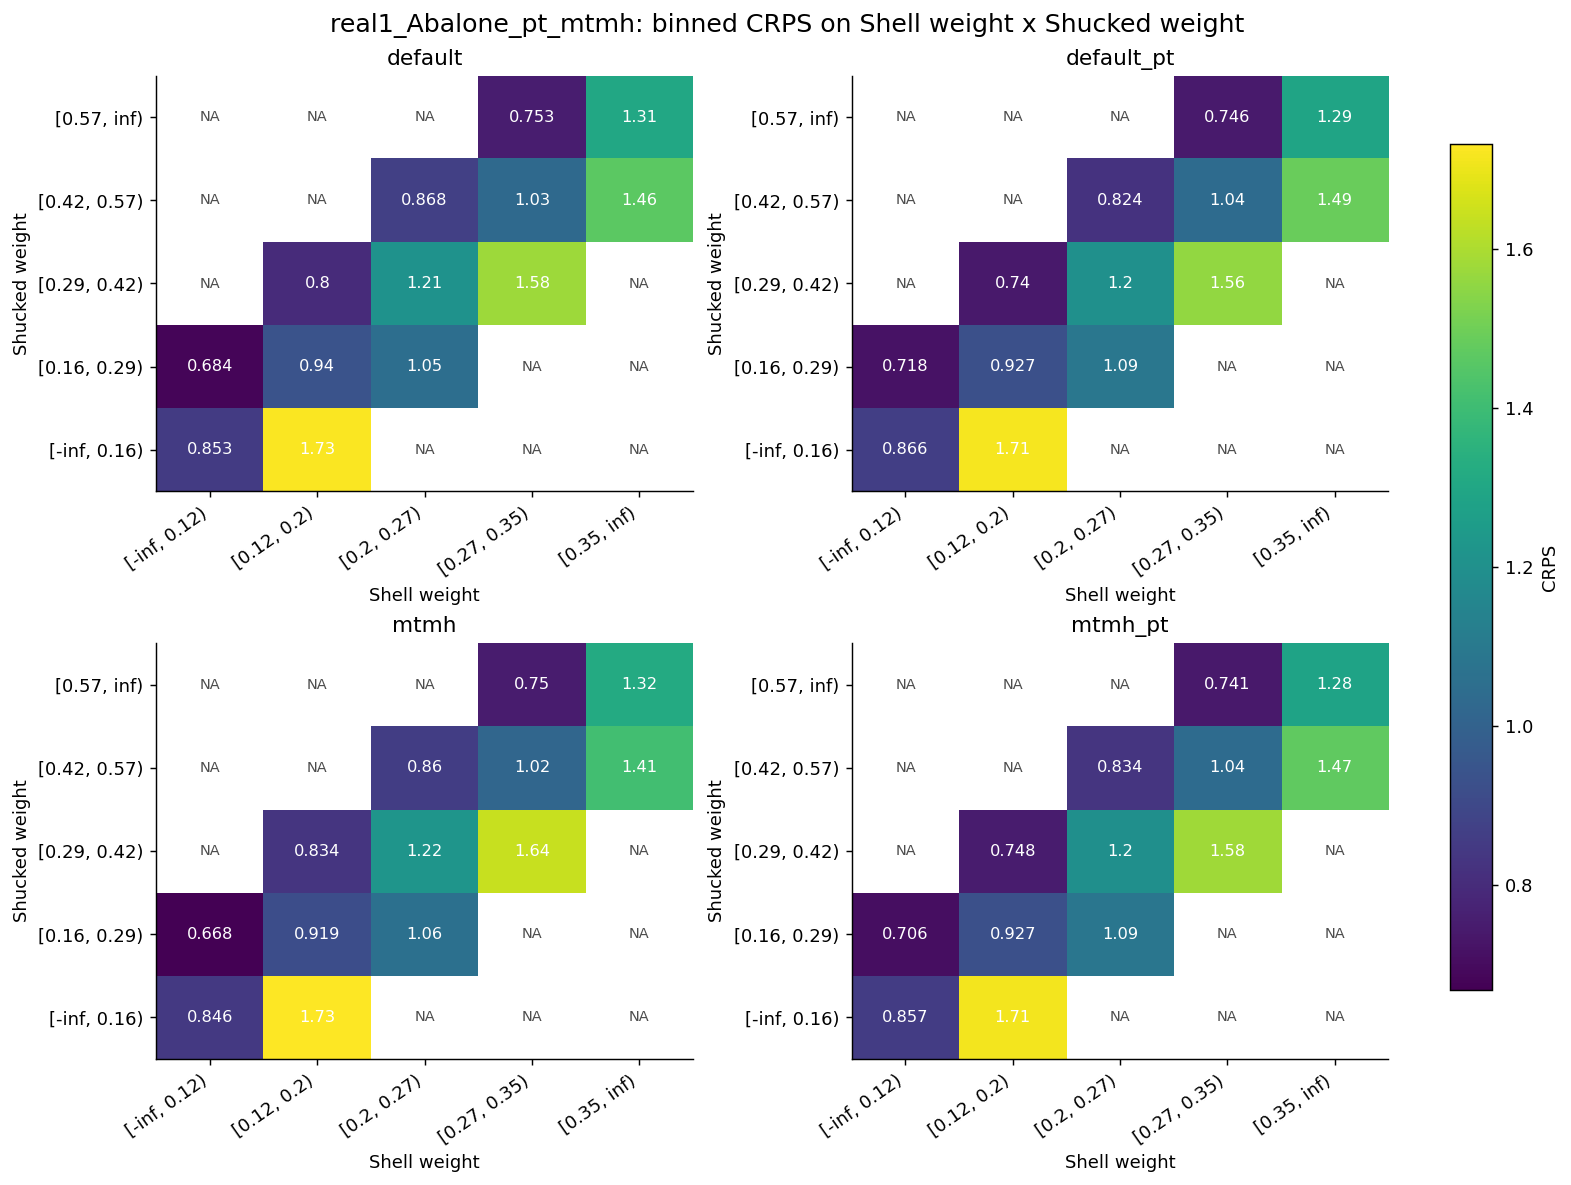


=== real2_WineQuality_pt_mtmh ===


,feature_index,feature,importance_mean,importance_std
0,10,alcohol,0.488127,0.022980
1,1,volatile acidity,0.226480,0.010314
2,5,free sulfur dioxide,0.116833,0.010939
3,9,sulphates,0.076483,0.004734
4,6,total sulfur dioxide,0.052606,0.004691
5,3,residual sugar,0.041637,0.003417
6,8,pH,0.039027,0.004029
7,2,citric acid,0.038125,0.003467
8,4,chlorides,0.034205,0.003065
9,7,density,0.030966,0.002049


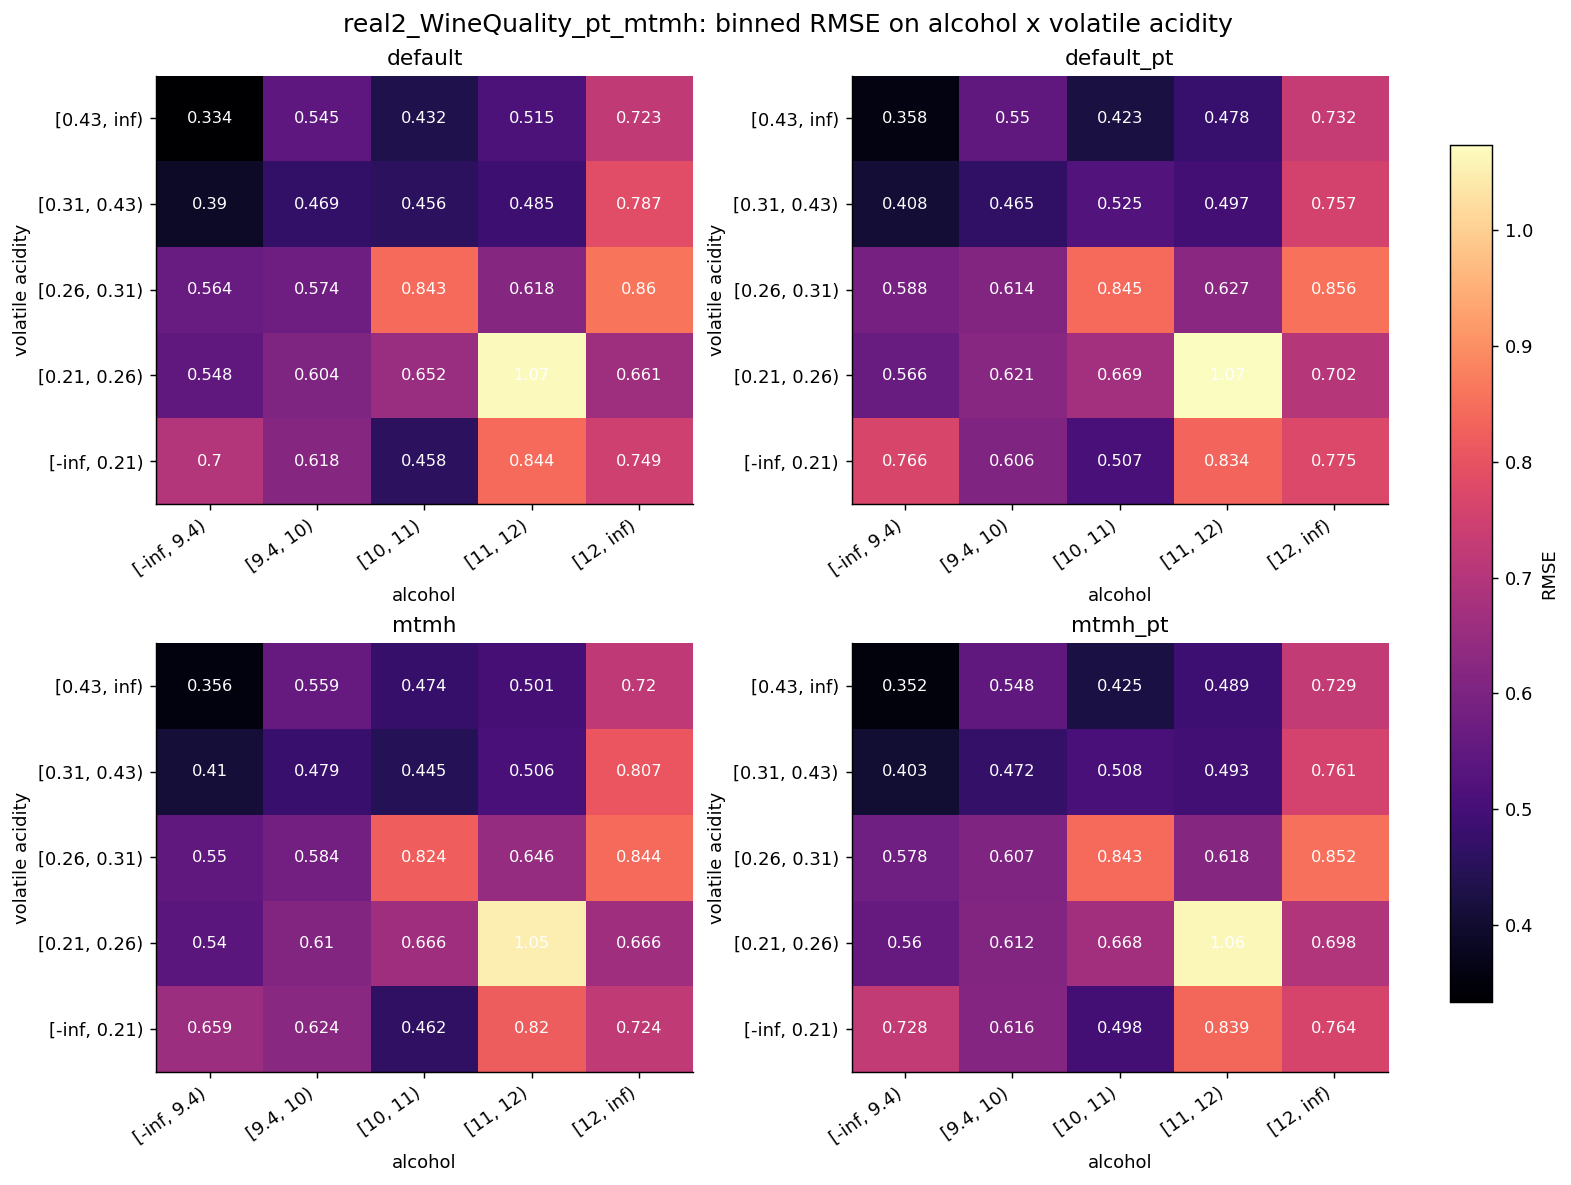

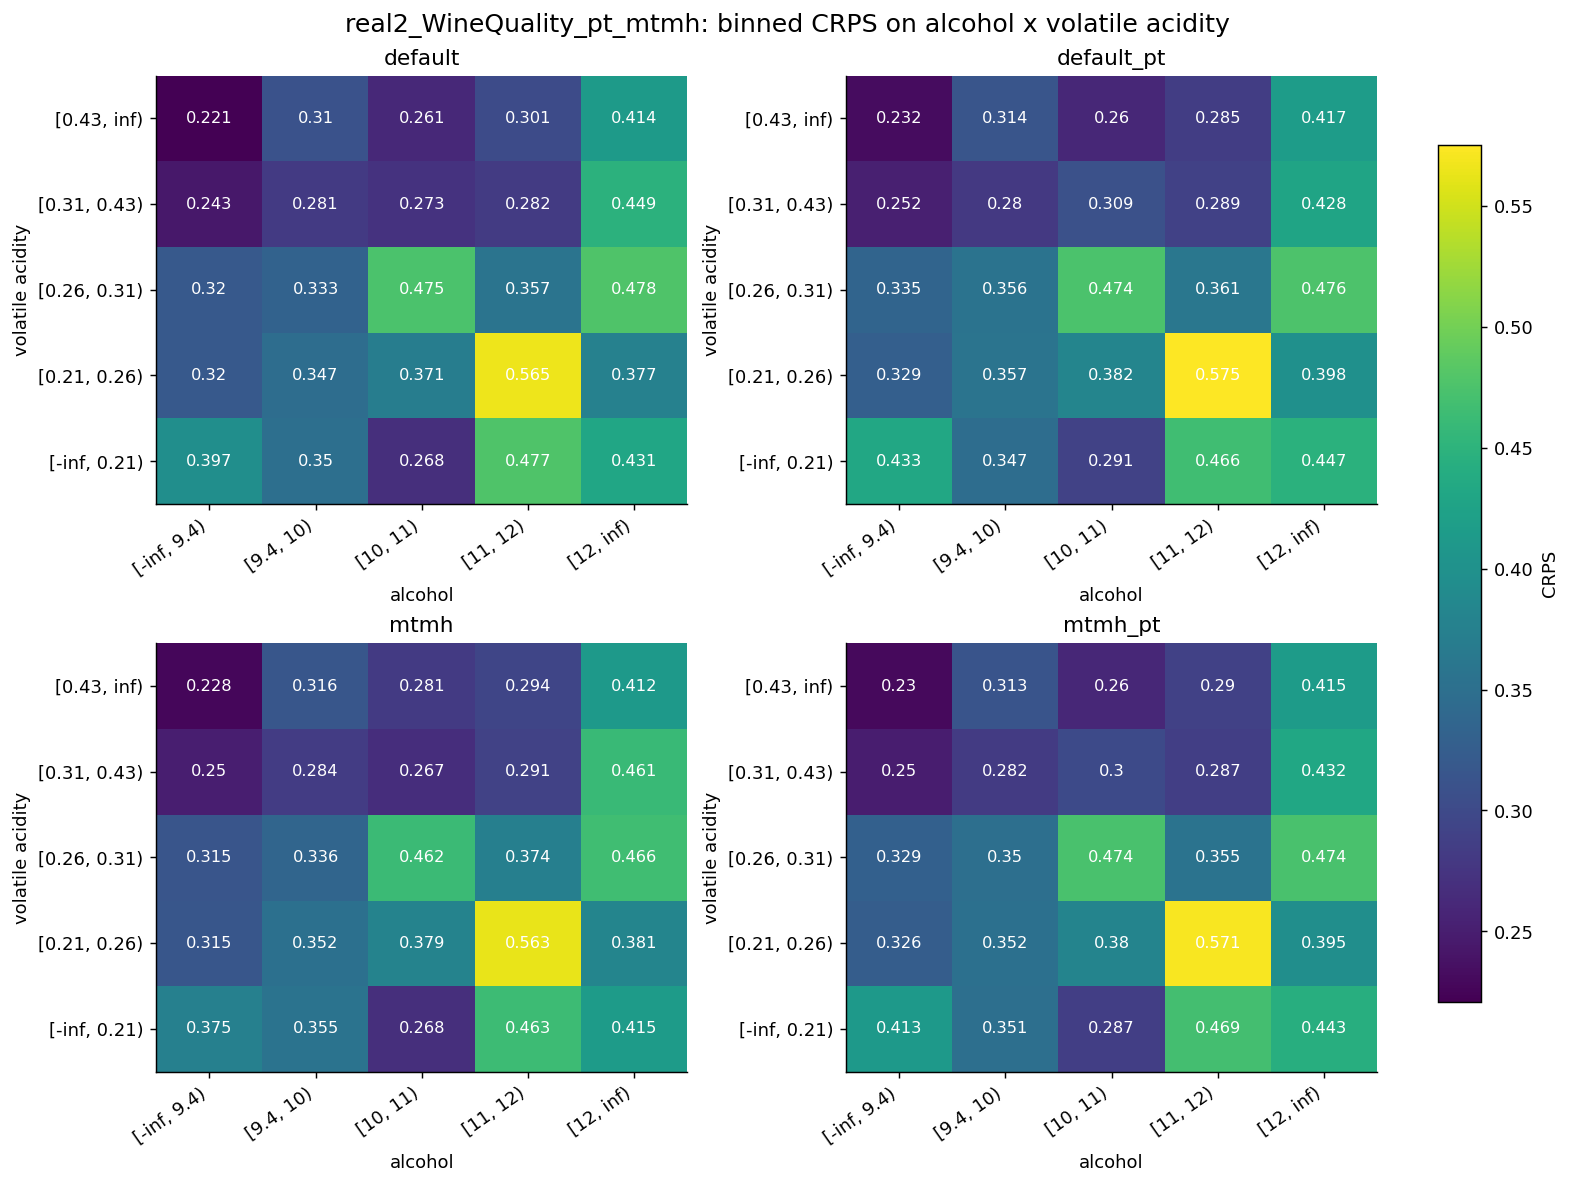


=== real3_CalHousing_pt_mtmh ===


,feature_index,feature,importance_mean,importance_std
0,0,MedInc,0.956029,0.057823
1,5,AveOccup,0.211043,0.018852
2,6,Latitude,0.115399,0.014232
3,7,Longitude,0.105957,0.009684
4,1,HouseAge,0.059250,0.011530
5,2,AveRooms,0.018135,0.004368
6,3,AveBedrms,0.006918,0.002940
7,4,Population,0.000258,0.004376


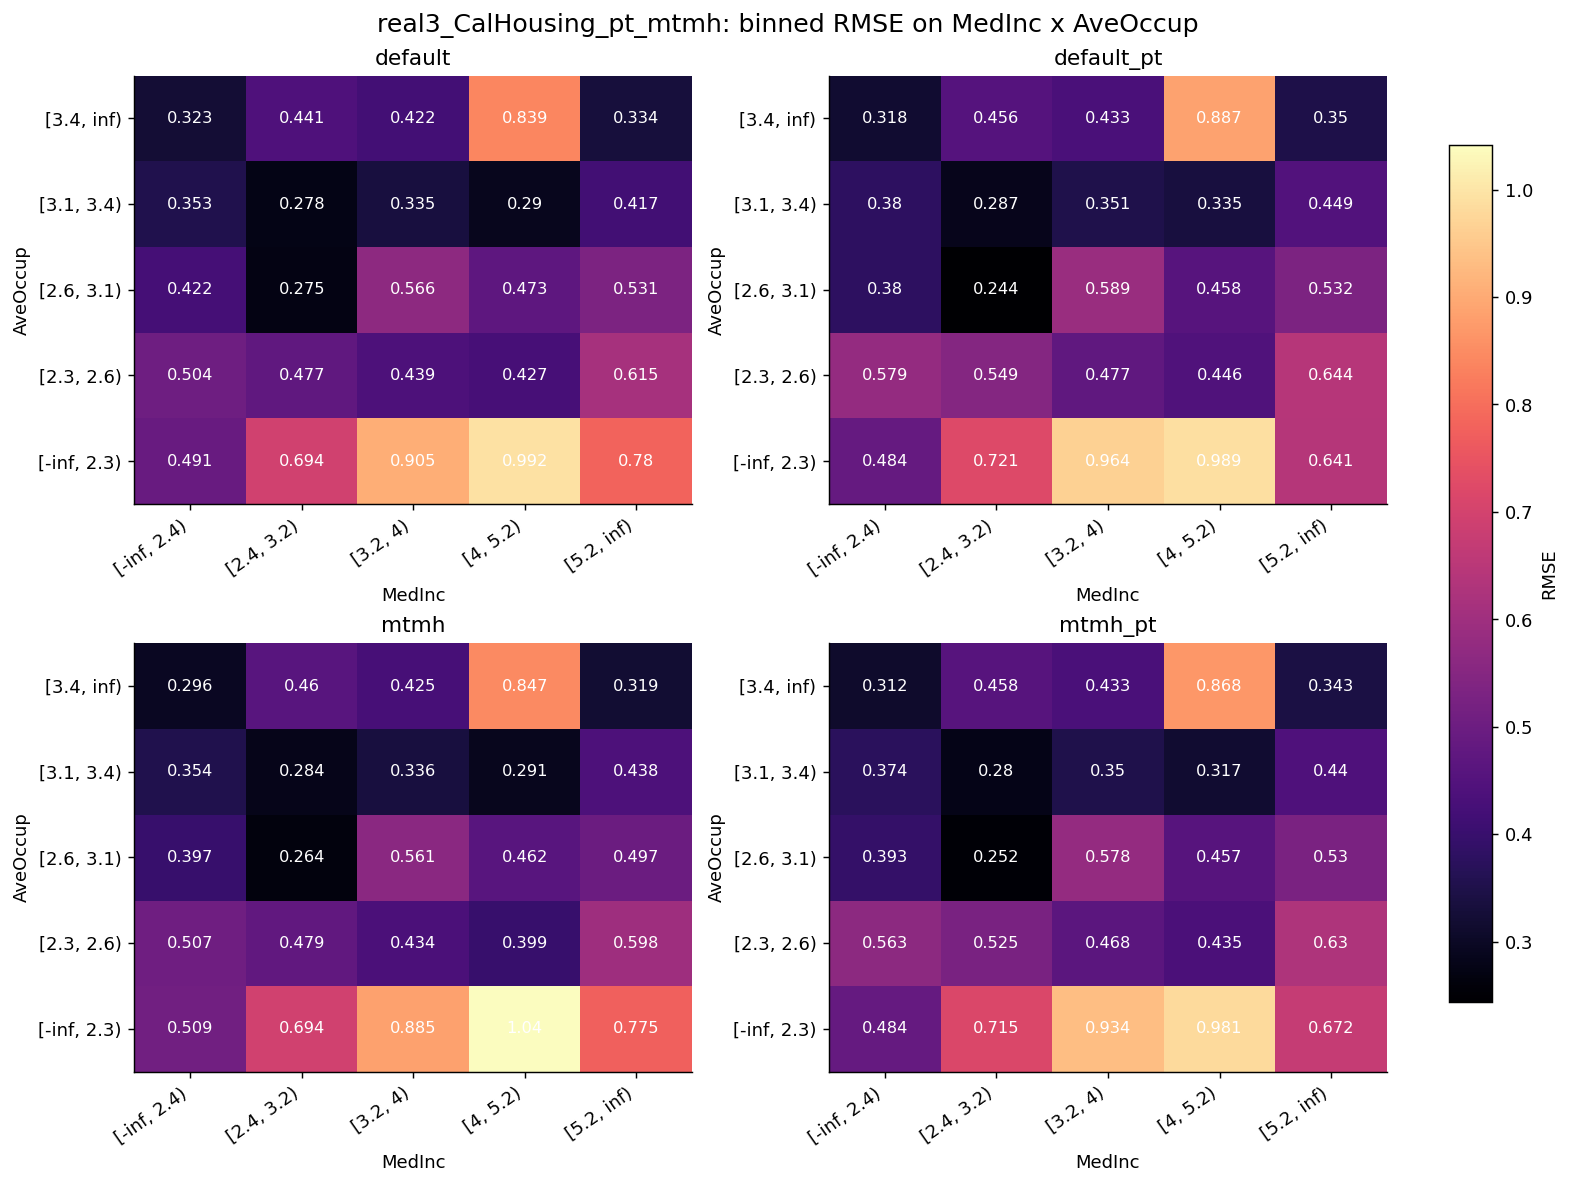

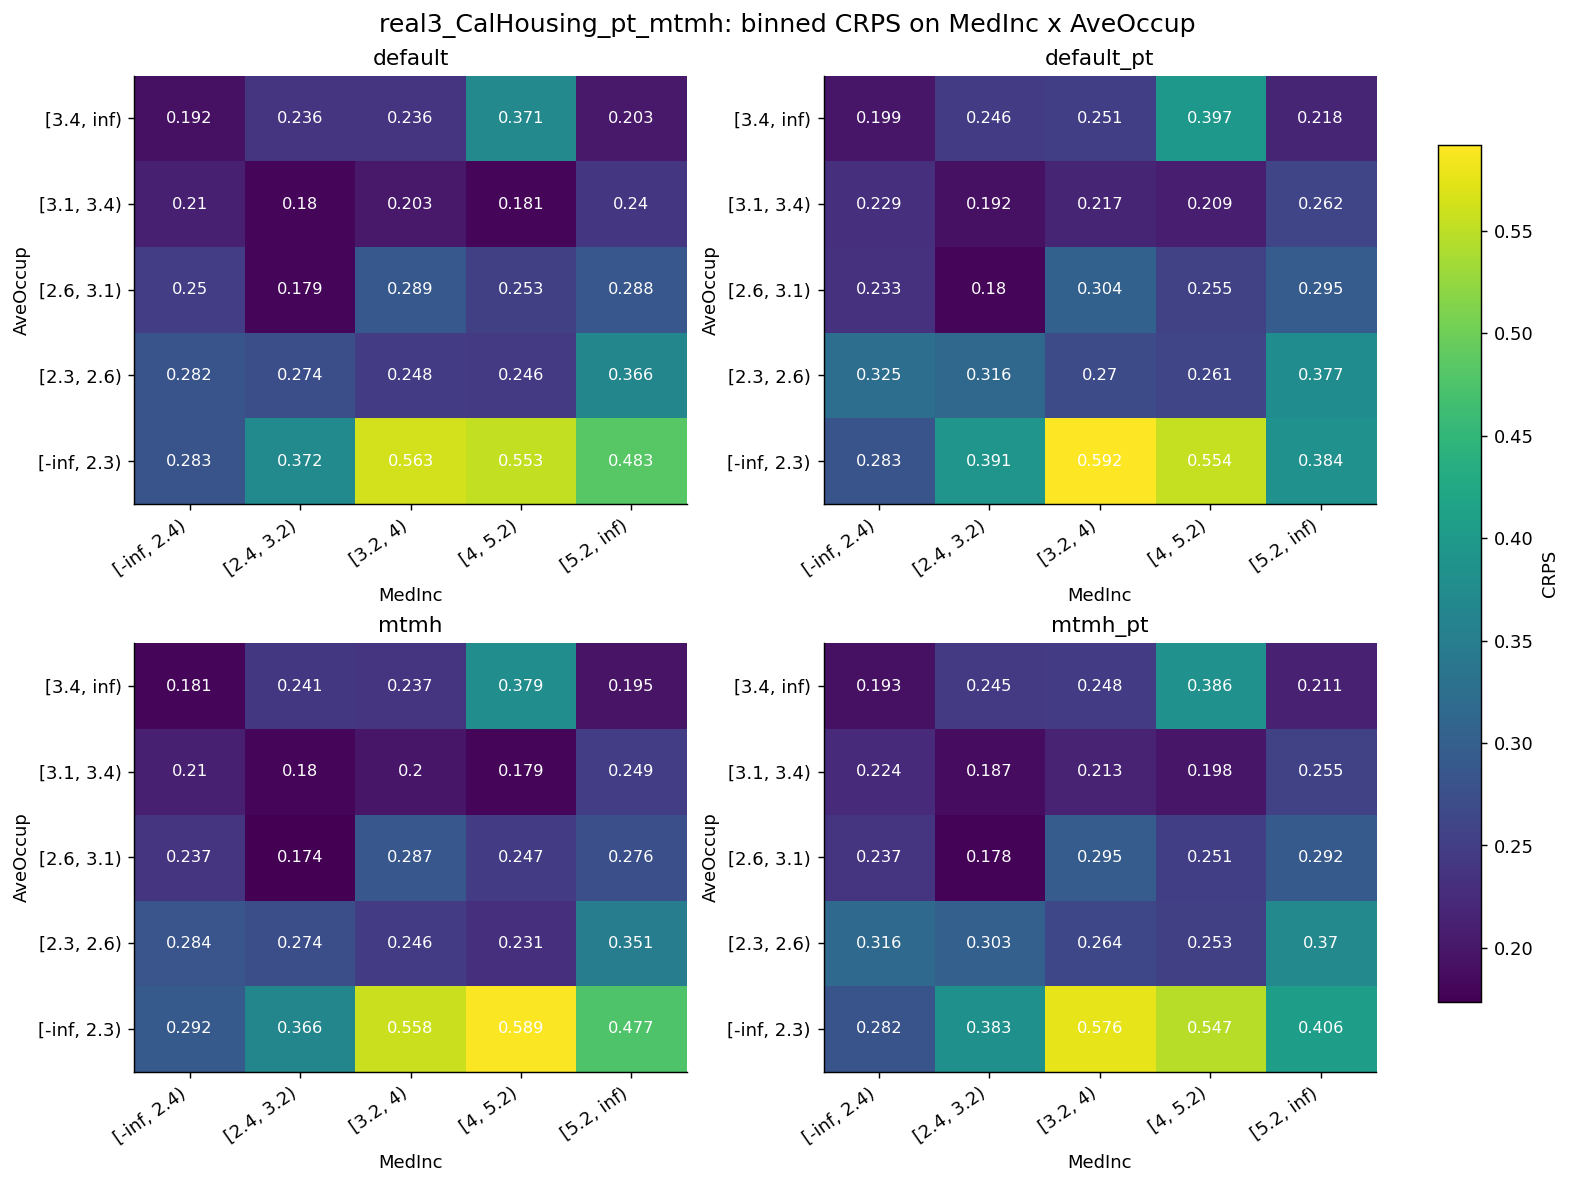


=== real4_Concrete_pt_mtmh ===


,feature_index,feature,importance_mean,importance_std
0,7,Age,0.658426,0.043071
1,0,Cement,0.580724,0.057352
2,3,Water,0.139597,0.014987
3,1,Blast Furnace Slag,0.128224,0.015317
4,4,Superplasticizer,0.087799,0.007408
5,6,Fine Aggregate,0.033773,0.004449
6,5,Coarse Aggregate,0.010137,0.001944
7,2,Fly Ash,0.009175,0.001826


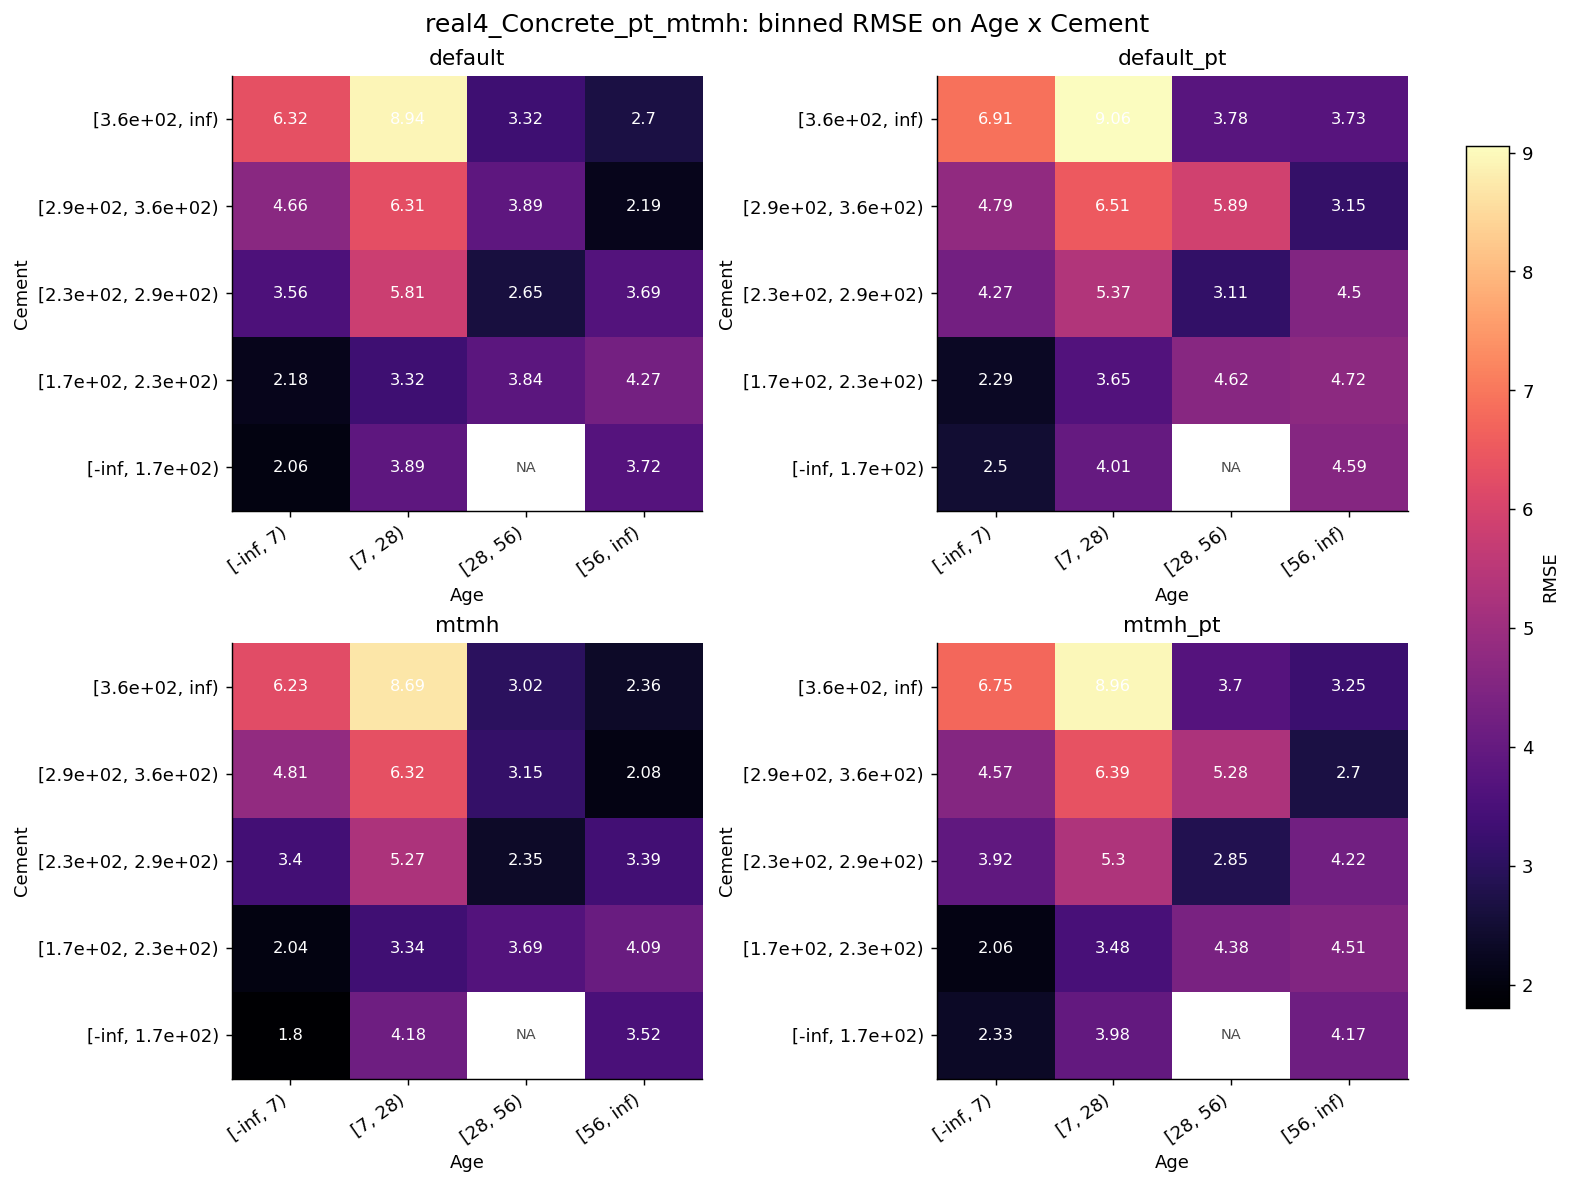

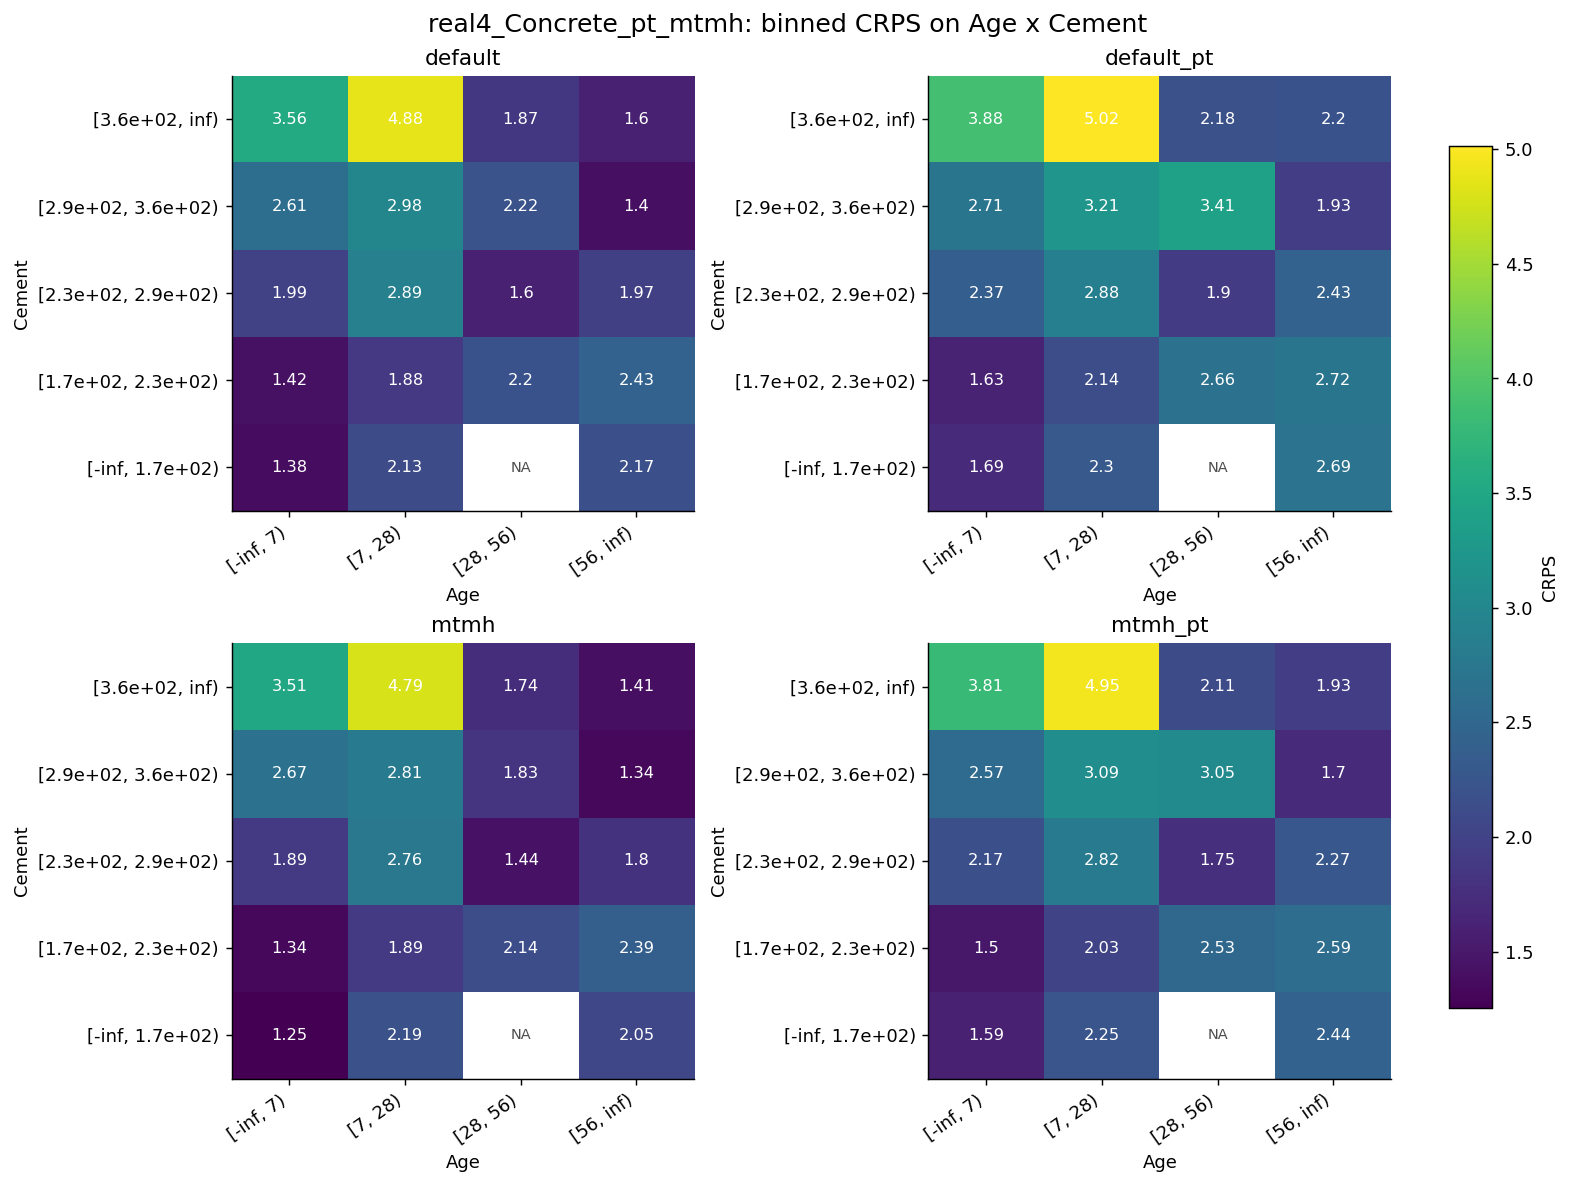


=== syn1_Friedman_pt_mtmh ===


,feature_index,feature,importance_mean,importance_std
0,3,x4,0.574730,0.029202
1,0,x1,0.440267,0.025298
2,1,x2,0.376226,0.026098
3,4,x5,0.133238,0.010980
4,2,x3,0.079282,0.003923
5,5,x6,0.000544,0.000427
6,7,x8,0.000135,0.000486
7,9,x10,0.000003,0.000576
8,6,x7,-0.000170,0.000429
9,8,x9,-0.000174,0.000398


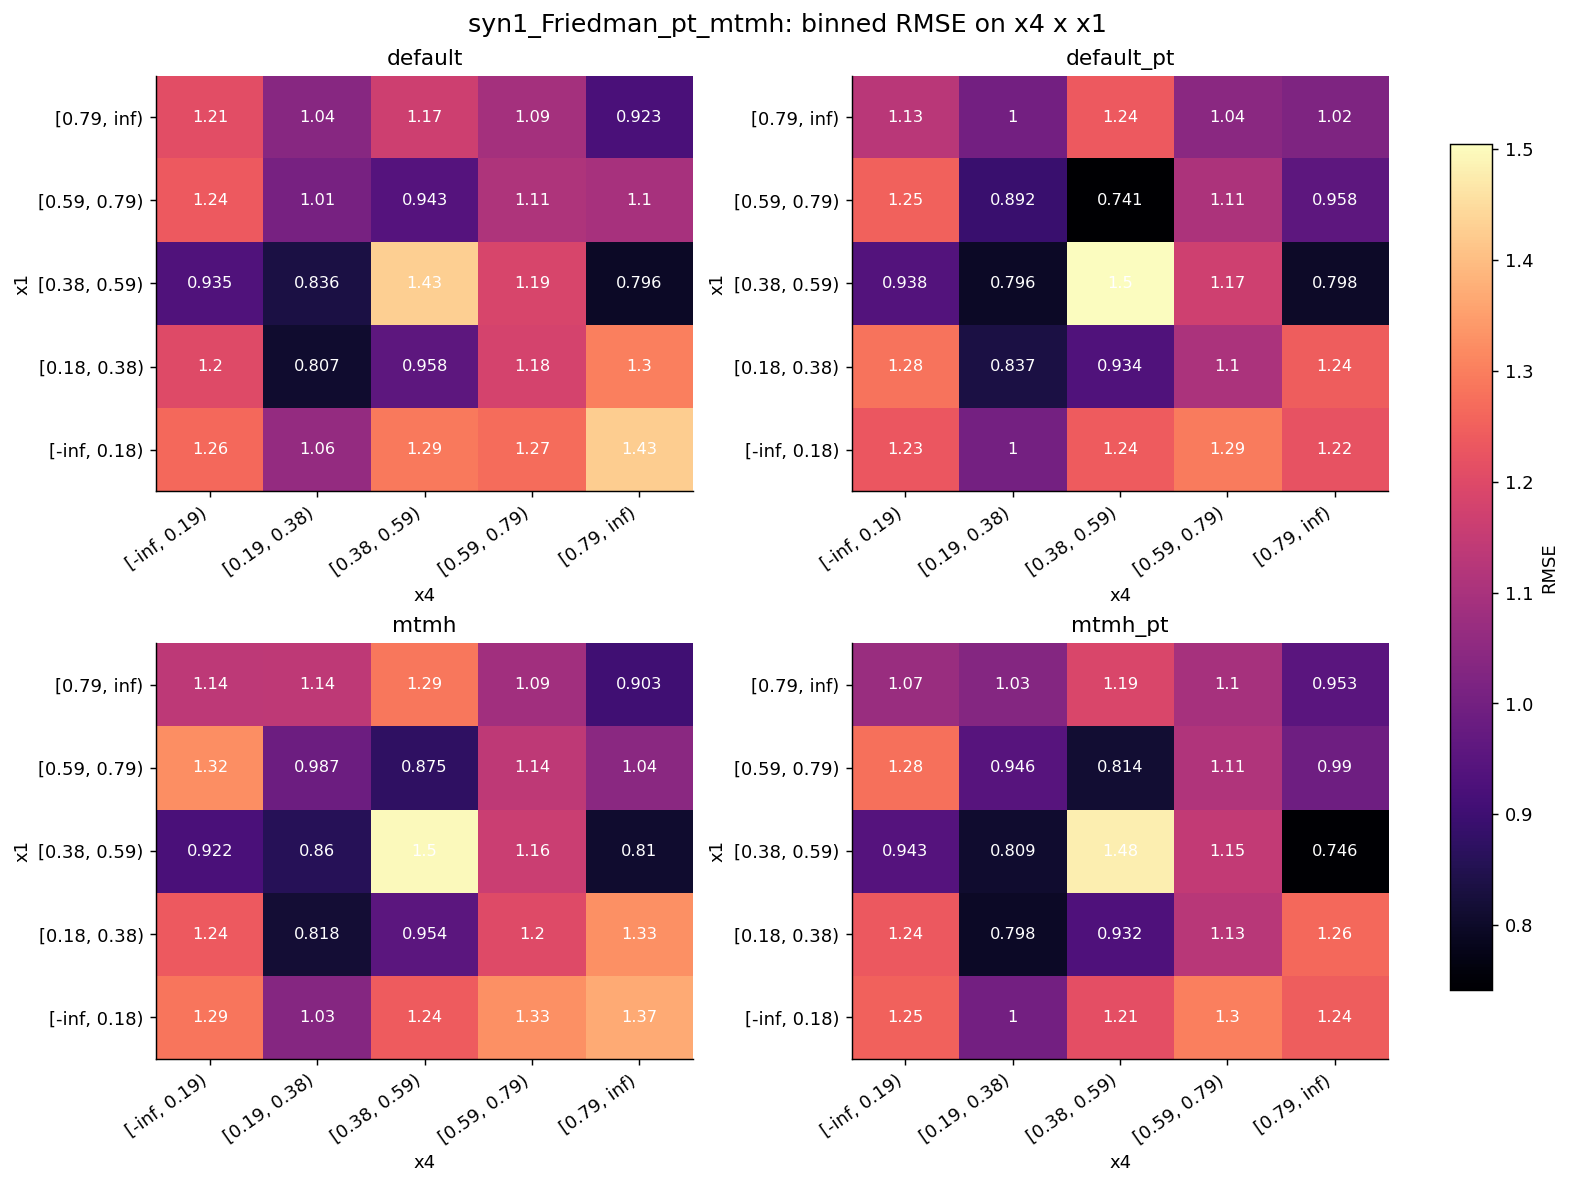

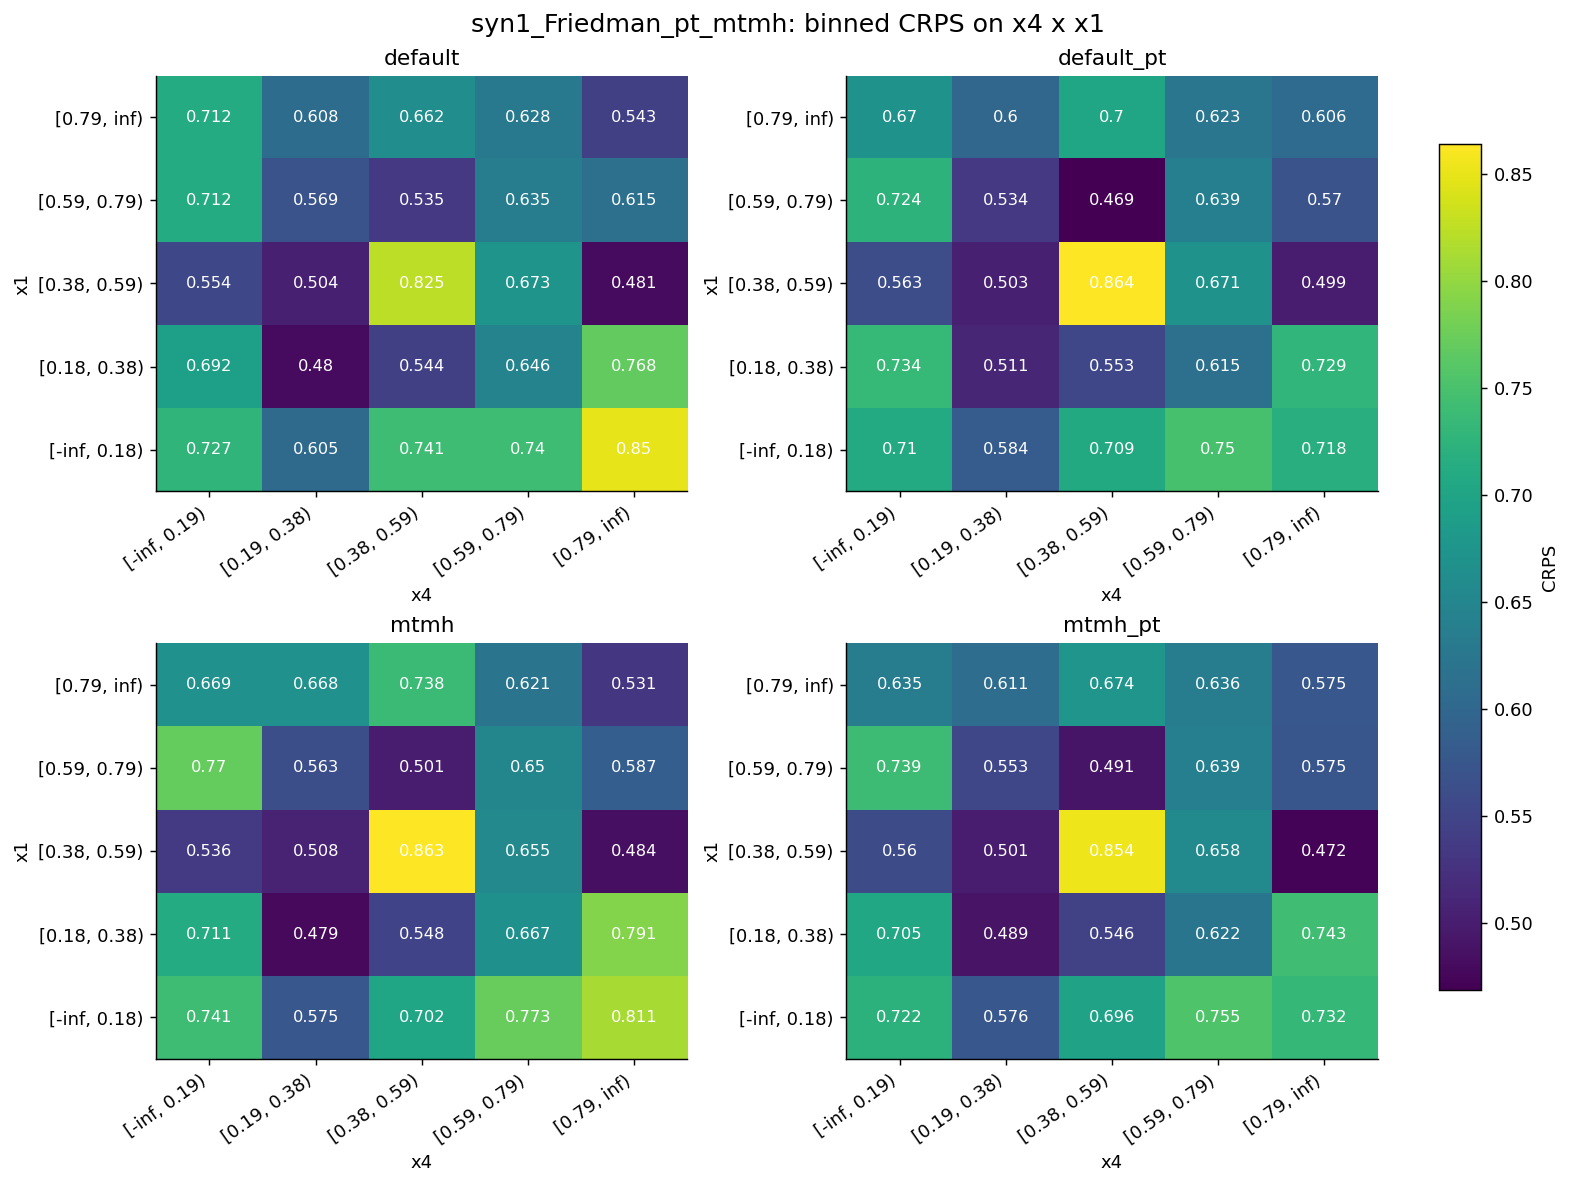

In [4]:
all_results = {}
all_binned_tables = []

for dataset in DATASETS:
    print(f"\n=== {dataset} ===")
    result = analyze_dataset(dataset)
    all_results[dataset] = result

    display(result["importance_table"])
    top_two = result["importance_table"].head(2)[["feature", "importance_mean", "importance_std"]]
    # display(top_two)

    binned = result["binned"].copy()
    binned.insert(0, "dataset", dataset)
    binned.insert(1, "feature_1", result["top_feature_names"][0])
    binned.insert(2, "feature_2", result["top_feature_names"][1])
    all_binned_tables.append(binned)

    rmse_fig, crps_fig = plot_dataset_metrics(result)
    if SAVE_FIGURES:
        save_figures(dataset, rmse_fig, crps_fig)
    plt.show()